In [1]:
# ============================================================
# CARE PROJECT — MACHINE LEARNING MODEL
# Climate Awareness and Risk Evaluation Dashboard
# ============================================================
# Student:    Ritesh Raju Ghorpade (202559288)
# Supervisor: Dr Daniel Thomas
# Deadline:   17th August 2026, noon UK time
# ============================================================
# Goal: Train a Random Forest classifier to predict
#       flood risk (Low/Medium/High) for Glasgow
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Machine learning
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report,
                             confusion_matrix,
                             f1_score, accuracy_score)
import shap

print("Libraries loaded!")

Libraries loaded!


In [2]:
# ── Load feature matrix ─────────────────────────────────────
BASE        = "/Users/riteshghorpade/Documents/010_Project/002_Dataset"
FEATURE_CSV = f"{BASE}/processed/feature_matrix.csv"
MAPS_PATH   = f"{BASE}/outputs"

df = pd.read_csv(FEATURE_CSV)

print("Feature matrix loaded!")
print(f"\nShape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nFirst 5 rows:")
print(df.head())

Feature matrix loaded!

Shape: (7843, 10)

Columns: ['elevation', 'dist_to_water', 'dist_to_clyde', 'building_count', 'road_count', 'mean_annual_mm_day', 'mean_winter_mm_day', 'wet_days_per_year', 'max_daily_mm', 'flood_risk']

First 5 rows:
   elevation  dist_to_water  dist_to_clyde  building_count  road_count  \
0          8     429.130538     429.130538              62          57   
1         17     808.615363    1228.448457              42          58   
2         14     724.363088    1135.327775              38          73   
3         13     644.627770    1043.142726              37          72   
4         12     571.303806     949.065747              44          71   

   mean_annual_mm_day  mean_winter_mm_day  wet_days_per_year  max_daily_mm  \
0              2.9601              3.4095              166.3        39.458   
1              2.8455              3.3141              163.7        37.886   
2              2.8455              3.3141              163.7        37.886   
3

In [3]:
# ── Prepare features and labels ─────────────────────────────
# X = features (input to model)
# y = flood_risk label (what model predicts)

feature_cols = ['elevation', 'dist_to_water', 'dist_to_clyde',
                'building_count', 'road_count', 'mean_annual_mm_day',
                'mean_winter_mm_day', 'wet_days_per_year', 'max_daily_mm']

X = df[feature_cols]
y = df['flood_risk']

print("Features (X):")
print(f"  Shape: {X.shape}")
print(f"  Columns: {X.columns.tolist()}")

print(f"\nLabel (y):")
print(f"  Shape: {y.shape}")
print(f"  Classes: {sorted(y.unique())}")
print(f"  Distribution:")
for cls in [0, 1, 2]:
    name  = {0:'Low', 1:'Medium', 2:'High'}[cls]
    count = (y==cls).sum()
    pct   = count/len(y)*100
    print(f"    Class {cls} ({name}): {count:,} ({pct:.1f}%)")

Features (X):
  Shape: (7843, 9)
  Columns: ['elevation', 'dist_to_water', 'dist_to_clyde', 'building_count', 'road_count', 'mean_annual_mm_day', 'mean_winter_mm_day', 'wet_days_per_year', 'max_daily_mm']

Label (y):
  Shape: (7843,)
  Classes: [np.int64(0), np.int64(1), np.int64(2)]
  Distribution:
    Class 0 (Low): 3,790 (48.3%)
    Class 1 (Medium): 2,698 (34.4%)
    Class 2 (High): 1,355 (17.3%)


In [5]:
# ── Train/test split ────────────────────────────────────────
# 80% training, 20% testing
# Stratified to maintain class distribution in both sets

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y  # ensures same class % in train and test
)

print("Train/test split complete!")
print(f"\nTraining set: {X_train.shape[0]:,} points (80%)")
print(f"Testing set:  {X_test.shape[0]:,} points (20%)")

print(f"\nTraining class distribution:")
for cls in [0, 1, 2]:
    name  = {0:'Low', 1:'Medium', 2:'High'}[cls]
    count = (y_train==cls).sum()
    pct   = count/len(y_train)*100
    print(f"  Class {cls} ({name}): {count:,} ({pct:.1f}%)")

print(f"\nTesting class distribution:")
for cls in [0, 1, 2]:
    name  = {0:'Low', 1:'Medium', 2:'High'}[cls]
    count = (y_test==cls).sum()
    pct   = count/len(y_test)*100
    print(f"  Class {cls} ({name}): {count:,} ({pct:.1f}%)")

Train/test split complete!

Training set: 6,274 points (80%)
Testing set:  1,569 points (20%)

Training class distribution:
  Class 0 (Low): 3,032 (48.3%)
  Class 1 (Medium): 2,158 (34.4%)
  Class 2 (High): 1,084 (17.3%)

Testing class distribution:
  Class 0 (Low): 758 (48.3%)
  Class 1 (Medium): 540 (34.4%)
  Class 2 (High): 271 (17.3%)


In [6]:
# ── Train baseline Random Forest ────────────────────────────
# Default settings first to establish baseline performance
# Then we will tune hyperparameters

print("Training baseline Random Forest...")

rf_baseline = RandomForestClassifier(
    n_estimators=100,  # 100 decision trees
    random_state=42,   # reproducible results
    n_jobs=-1          # use all CPU cores
)

rf_baseline.fit(X_train, y_train)

print("Training complete!")

# Evaluate on test set
y_pred = rf_baseline.predict(X_test)

print(f"\nBaseline Model Performance:")
print(f"  Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"  F1 Score (macro): {f1_score(y_test, y_pred, average='macro'):.4f}")
print(f"  F1 Score (weighted): {f1_score(y_test, y_pred, average='weighted'):.4f}")

Training baseline Random Forest...
Training complete!

Baseline Model Performance:
  Accuracy: 0.9955
  F1 Score (macro): 0.9942
  F1 Score (weighted): 0.9955


In [7]:
# ── Classification report ───────────────────────────────────
print("Detailed Classification Report:")
print("=" * 55)
print(classification_report(
    y_test, y_pred,
    target_names=['Low risk', 'Medium risk', 'High risk']
))

Detailed Classification Report:
              precision    recall  f1-score   support

    Low risk       1.00      0.99      1.00       758
 Medium risk       1.00      1.00      1.00       540
   High risk       0.99      0.99      0.99       271

    accuracy                           1.00      1569
   macro avg       0.99      0.99      0.99      1569
weighted avg       1.00      1.00      1.00      1569



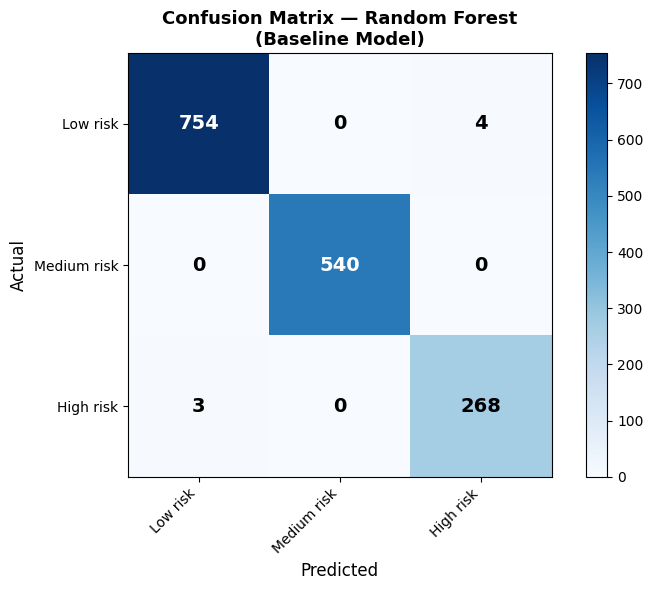

Saved!


In [8]:
# ── Confusion matrix ────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(cm, cmap='Blues')
plt.colorbar(im)

classes = ['Low risk', 'Medium risk', 'High risk']
ax.set_xticks(range(3))
ax.set_yticks(range(3))
ax.set_xticklabels(classes, rotation=45, ha='right')
ax.set_yticklabels(classes)

for i in range(3):
    for j in range(3):
        ax.text(j, i, cm[i,j], ha='center', va='center',
                fontsize=14, fontweight='bold',
                color='white' if cm[i,j] > cm.max()/2 else 'black')

ax.set_xlabel("Predicted", fontsize=12)
ax.set_ylabel("Actual", fontsize=12)
ax.set_title("Confusion Matrix — Random Forest\n(Baseline Model)",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{MAPS_PATH}/confusion_matrix.png", dpi=150)
plt.show()
print("Saved!")

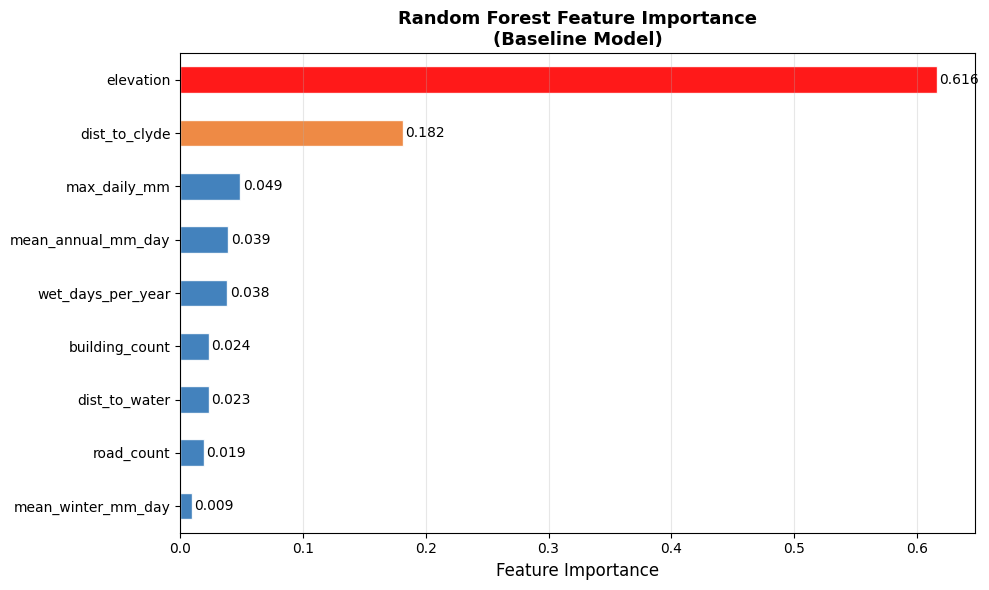

Feature importance:
  elevation              0.6164
  dist_to_clyde          0.1815
  max_daily_mm           0.0490
  mean_annual_mm_day     0.0391
  wet_days_per_year      0.0384
  building_count         0.0235
  dist_to_water          0.0233
  road_count             0.0194
  mean_winter_mm_day     0.0094


In [9]:
# ── Feature importance ──────────────────────────────────────
importances = rf_baseline.feature_importances_
feat_imp = pd.Series(importances, index=feature_cols).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#FF0000' if v >= 0.3 else '#ED7D31' if v >= 0.1 else '#2E75B6'
          for v in feat_imp.values]
feat_imp.plot.barh(ax=ax, color=colors, edgecolor='white', alpha=0.9)

ax.set_xlabel("Feature Importance", fontsize=12)
ax.set_title("Random Forest Feature Importance\n(Baseline Model)",
             fontsize=13, fontweight='bold')
ax.grid(axis='x', alpha=0.3)

for i, v in enumerate(feat_imp.values):
    ax.text(v + 0.002, i, f"{v:.3f}", va='center', fontsize=10)

plt.tight_layout()
plt.savefig(f"{MAPS_PATH}/feature_importance.png", dpi=150)
plt.show()

print("Feature importance:")
for feat, imp in feat_imp.sort_values(ascending=False).items():
    print(f"  {feat:<22} {imp:.4f}")

In [10]:
# ── SHAP Analysis ───────────────────────────────────────────
# SHAP explains WHY the model made each prediction
# This is the core of your unique research contribution

print("Running SHAP analysis...")
print("This may take 2-3 minutes...")

# Use a sample for speed
X_sample = X_test.sample(n=500, random_state=42)

# Create SHAP explainer
explainer = shap.TreeExplainer(rf_baseline)
shap_values = explainer.shap_values(X_sample)

print("SHAP analysis complete!")
print(f"SHAP values shape: {np.array(shap_values).shape}")

Running SHAP analysis...
This may take 2-3 minutes...
SHAP analysis complete!
SHAP values shape: (500, 9, 3)


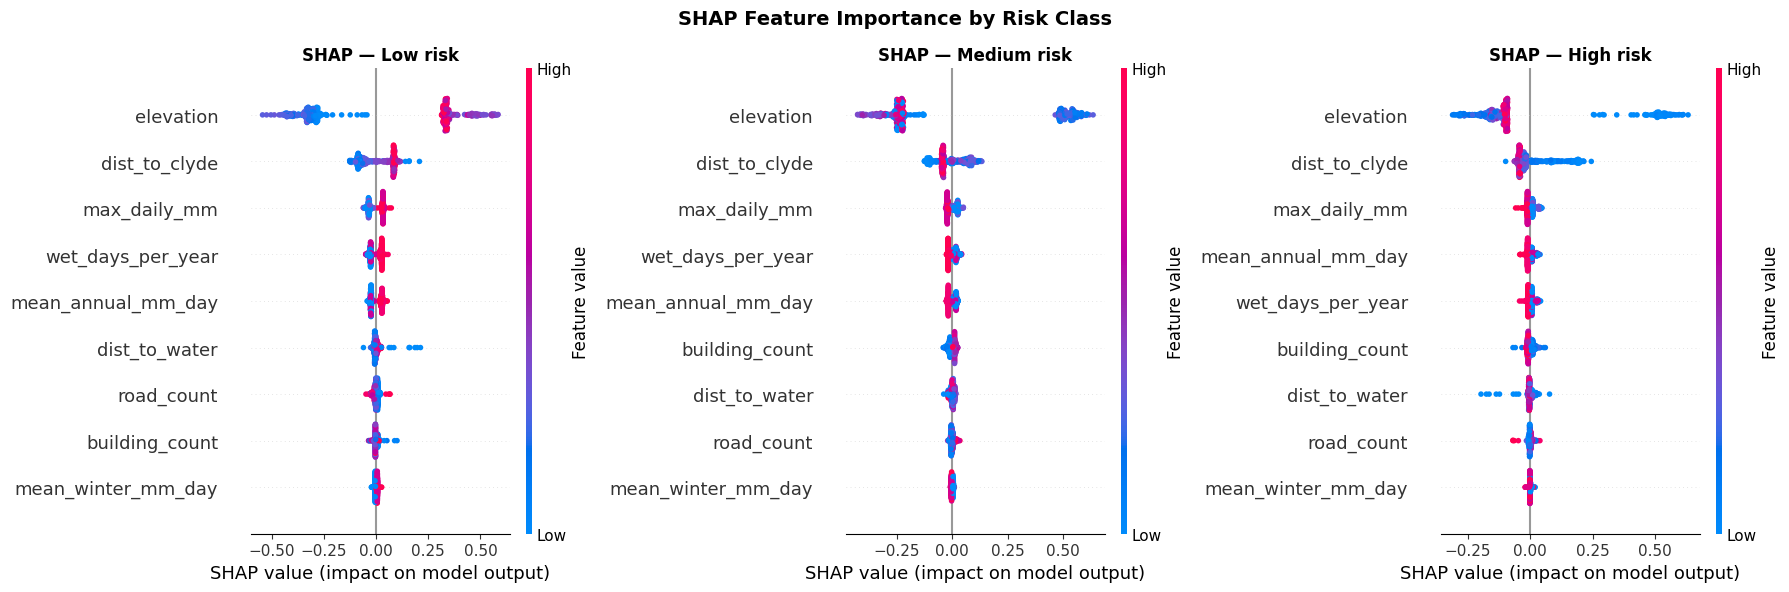

SHAP summary saved!


In [11]:
# ── SHAP Summary Plot ───────────────────────────────────────
# Shows which features matter most for each prediction
# and in which direction they push the prediction

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
class_names = ['Low risk', 'Medium risk', 'High risk']

for i, (ax, name) in enumerate(zip(axes, class_names)):
    plt.sca(ax)
    shap.summary_plot(
        shap_values[:, :, i],
        X_sample,
        feature_names=feature_cols,
        show=False,
        plot_size=None
    )
    ax.set_title(f"SHAP — {name}", fontsize=12, fontweight='bold')

plt.suptitle("SHAP Feature Importance by Risk Class",
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{MAPS_PATH}/shap_summary.png", dpi=150, bbox_inches='tight')
plt.show()
print("SHAP summary saved!")

In [12]:
import numpy as np

# Assuming you already have:
# - shap_values: SHAP values for your 500 test samples (list of arrays, one per class)
# - X_test_sample: the corresponding feature rows
# - y_pred: model predictions for those 500 samples

# Find a confident Low risk example (class 0)
low_risk_idx = np.where(y_pred == 0)[0][0]

# Find a confident High risk example (class 2)
high_risk_idx = np.where(y_pred == 2)[0][0]

print("Low risk example index:", low_risk_idx)
print("High risk example index:", high_risk_idx)

Low risk example index: 0
High risk example index: 1


In [15]:
%whos DataFrame

Variable   Type         Data/Info
---------------------------------
X          DataFrame          elevation  dist_to_<...>\n[7843 rows x 9 columns]
X_sample   DataFrame          elevation  dist_to_<...>n\n[500 rows x 9 columns]
X_test     DataFrame          elevation  dist_to_<...>\n[1569 rows x 9 columns]
X_train    DataFrame          elevation  dist_to_<...>\n[6274 rows x 9 columns]
df         DataFrame          elevation  dist_to_<...>n[7843 rows x 10 columns]


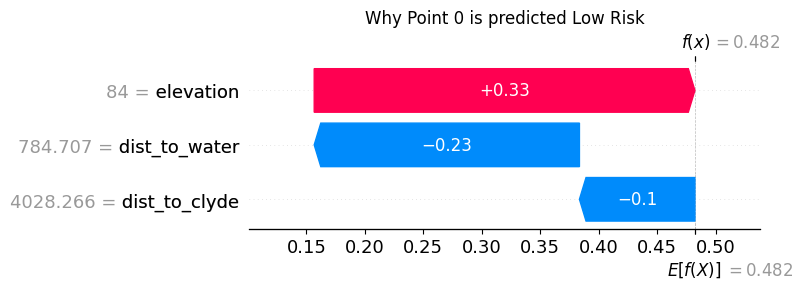

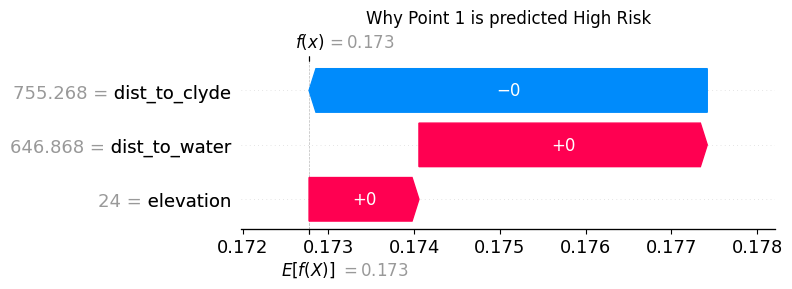

In [16]:
import shap
import matplotlib.pyplot as plt

# --- Low risk example ---
plt.figure()
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[0][low_risk_idx],
        base_values=explainer.expected_value[0],
        data=X_sample.iloc[low_risk_idx],
        feature_names=X_sample.columns.tolist()
    ),
    show=False
)
plt.title(f"Why Point {low_risk_idx} is predicted Low Risk")
plt.tight_layout()
plt.savefig("shap_waterfall_low_risk.png", dpi=150)
plt.show()

# --- High risk example ---
plt.figure()
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[2][high_risk_idx],
        base_values=explainer.expected_value[2],
        data=X_sample.iloc[high_risk_idx],
        feature_names=X_sample.columns.tolist()
    ),
    show=False
)
plt.title(f"Why Point {high_risk_idx} is predicted High Risk")
plt.tight_layout()
plt.savefig("shap_waterfall_high_risk.png", dpi=150)
plt.show()

In [17]:
import numpy as np
print(np.array(shap_values).shape)

(500, 9, 3)


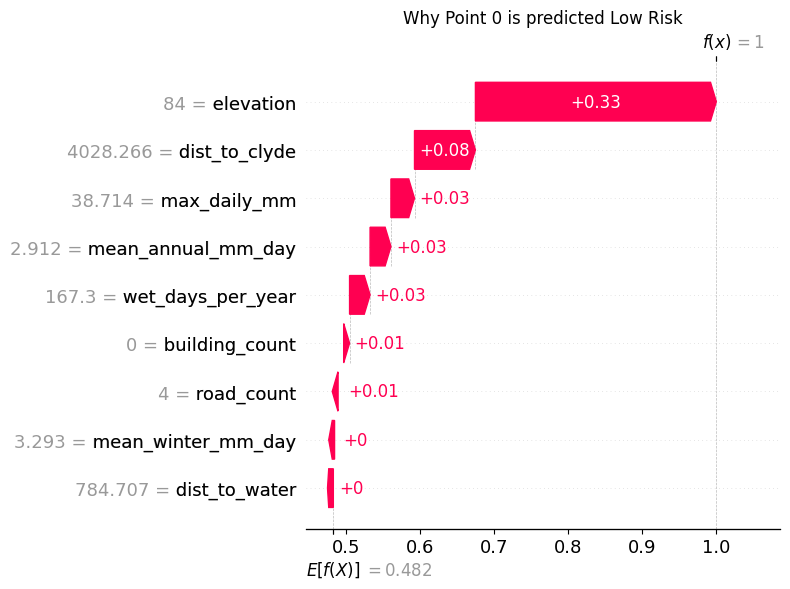

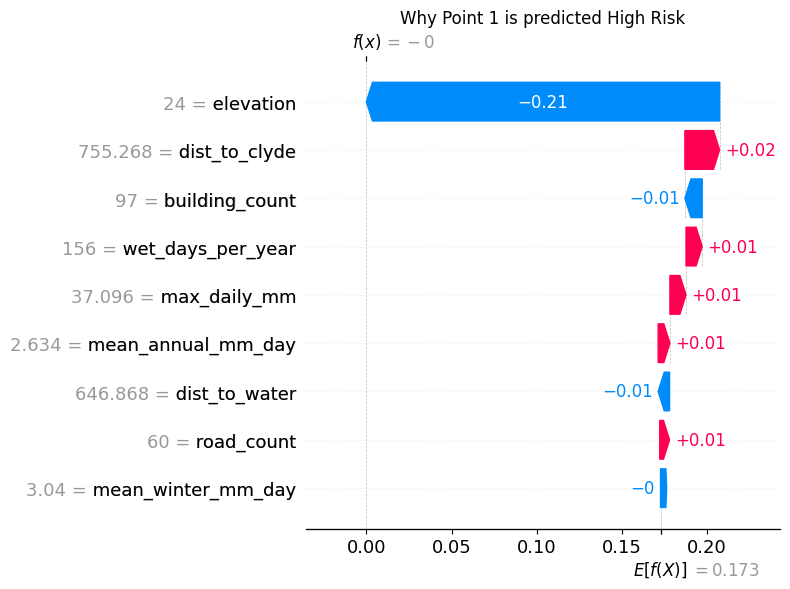

In [18]:
import shap
import matplotlib.pyplot as plt

# --- Low risk example ---
plt.figure()
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[low_risk_idx, :, 0],        # all 9 features, class 0 (Low), this point
        base_values=explainer.expected_value[0],
        data=X_sample.iloc[low_risk_idx],
        feature_names=X_sample.columns.tolist()
    ),
    show=False
)
plt.title(f"Why Point {low_risk_idx} is predicted Low Risk")
plt.tight_layout()
plt.savefig("shap_waterfall_low_risk.png", dpi=150)
plt.show()

# --- High risk example ---
plt.figure()
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[high_risk_idx, :, 2],       # all 9 features, class 2 (High), this point
        base_values=explainer.expected_value[2],
        data=X_sample.iloc[high_risk_idx],
        feature_names=X_sample.columns.tolist()
    ),
    show=False
)
plt.title(f"Why Point {high_risk_idx} is predicted High Risk")
plt.tight_layout()
plt.savefig("shap_waterfall_high_risk.png", dpi=150)
plt.show()

In [21]:
%whos RandomForestClassifier

Variable      Type                      Data/Info
-------------------------------------------------
rf_baseline   RandomForestClassifier    RandomForestClassifier(n_<...>jobs=-1, random_state=42)


In [23]:
import shap

# Rebuild the explainer so SHAP values are in probability space
explainer_proba = shap.TreeExplainer(
    rf_baseline,
    data=X_train,                     # background dataset for probability calibration
    model_output="probability"
)

# Recompute SHAP values for your 500-sample set
shap_values_proba = explainer_proba.shap_values(X_sample)

print(np.array(shap_values_proba).shape)

(500, 9, 3)


Most confident Low risk index: 0 prob: 1.0
Most confident High risk index: 4 prob: 1.0


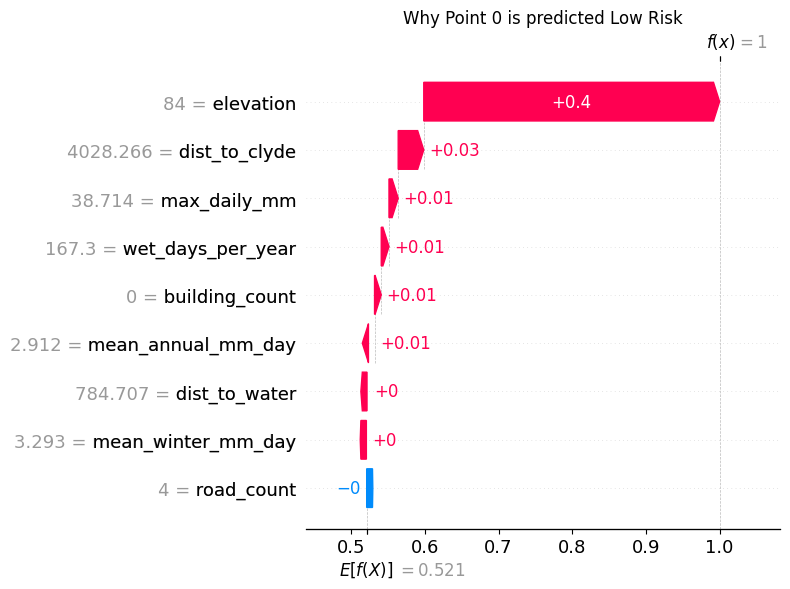

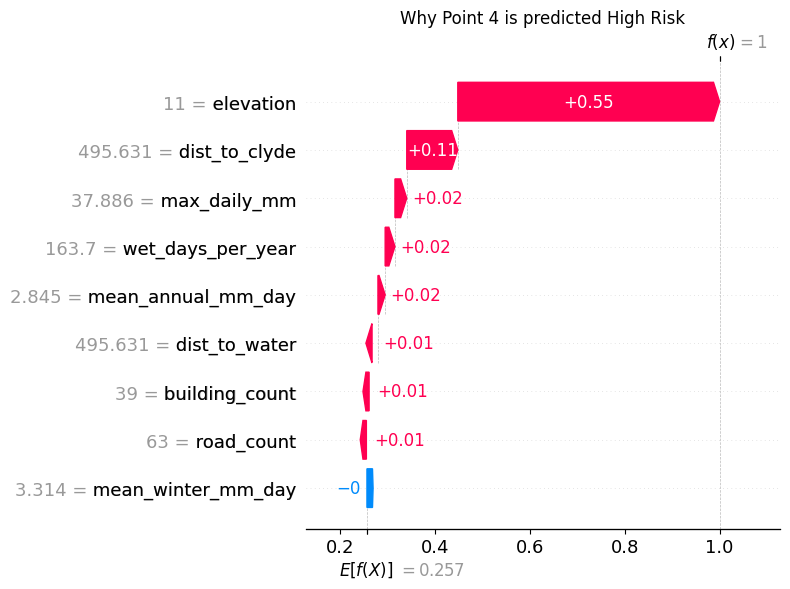

In [24]:
probs = rf_baseline.predict_proba(X_sample)

low_risk_idx = np.argmax(probs[:, 0])
high_risk_idx = np.argmax(probs[:, 2])

print("Most confident Low risk index:", low_risk_idx, "prob:", probs[low_risk_idx, 0])
print("Most confident High risk index:", high_risk_idx, "prob:", probs[high_risk_idx, 2])

# --- Low risk example ---
plt.figure()
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values_proba[low_risk_idx, :, 0],
        base_values=explainer_proba.expected_value[0],
        data=X_sample.iloc[low_risk_idx],
        feature_names=X_sample.columns.tolist()
    ),
    show=False
)
plt.title(f"Why Point {low_risk_idx} is predicted Low Risk")
plt.tight_layout()
plt.savefig("shap_waterfall_low_risk_proba.png", dpi=150)
plt.show()

# --- High risk example ---
plt.figure()
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values_proba[high_risk_idx, :, 2],
        base_values=explainer_proba.expected_value[2],
        data=X_sample.iloc[high_risk_idx],
        feature_names=X_sample.columns.tolist()
    ),
    show=False
)
plt.title(f"Why Point {high_risk_idx} is predicted High Risk")
plt.tight_layout()
plt.savefig("shap_waterfall_high_risk_proba.png", dpi=150)
plt.show()

In [25]:
import pandas as pd

# Check 1: how many points have dist_to_clyde exactly equal to dist_to_water?
exact_matches = (df['dist_to_clyde'] == df['dist_to_water']).sum()
print(f"Points where dist_to_clyde == dist_to_water exactly: {exact_matches} out of {len(df)}")

# Check 2: how correlated are the two columns overall?
corr = df['dist_to_clyde'].corr(df['dist_to_water'])
print(f"Correlation between dist_to_clyde and dist_to_water: {corr:.4f}")

# Check 3: look at a broader sample of rows where they're close or equal
close_matches = df[np.isclose(df['dist_to_clyde'], df['dist_to_water'], atol=0.01)]
print(f"Points where they're nearly identical (within 0.01m): {len(close_matches)}")
print(close_matches[['dist_to_clyde', 'dist_to_water']].head(10))

Points where dist_to_clyde == dist_to_water exactly: 1426 out of 7843
Correlation between dist_to_clyde and dist_to_water: 0.2515
Points where they're nearly identical (within 0.01m): 1426
    dist_to_clyde  dist_to_water
0      429.130538     429.130538
10     382.370562     382.370562
11     293.976532     293.976532
12     205.601895     205.601895
13     127.246622     127.246622
14      97.786094      97.786094
15      70.416797      70.416797
16       0.000000       0.000000
17       0.000000       0.000000
18      20.485543      20.485543


Most confident Medium risk index: 1 prob: 1.0


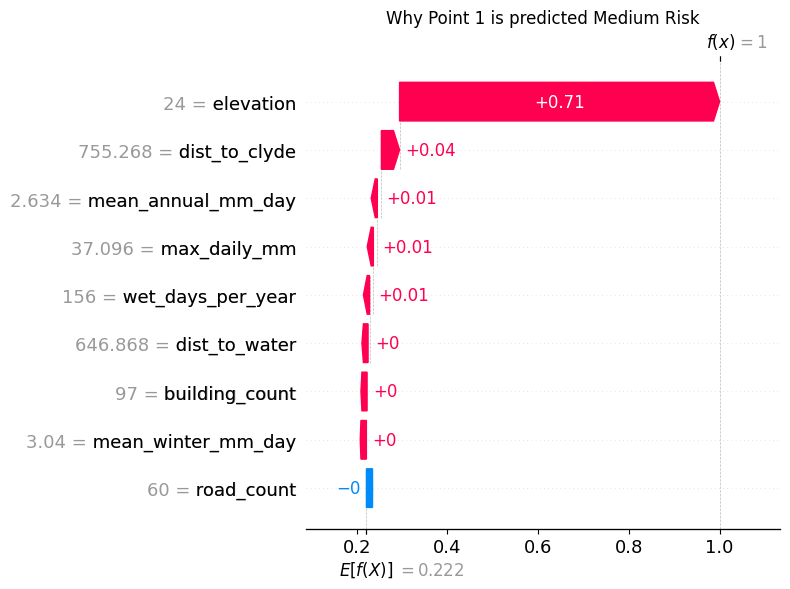

In [26]:
# Most confident Medium risk point (class 1)
medium_risk_idx = np.argmax(probs[:, 1])

print("Most confident Medium risk index:", medium_risk_idx, "prob:", probs[medium_risk_idx, 1])

plt.figure()
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values_proba[medium_risk_idx, :, 1],
        base_values=explainer_proba.expected_value[1],
        data=X_sample.iloc[medium_risk_idx],
        feature_names=X_sample.columns.tolist()
    ),
    show=False
)
plt.title(f"Why Point {medium_risk_idx} is predicted Medium Risk")
plt.tight_layout()
plt.savefig("shap_waterfall_medium_risk_proba.png", dpi=150)
plt.show()

In [27]:
print(X_sample.iloc[[low_risk_idx, high_risk_idx, medium_risk_idx]])

      elevation  dist_to_water  dist_to_clyde  building_count  road_count  \
7389         84     784.706612    4028.265628               0           4   
2341         11     495.631422     495.631422              39          63   
4805         24     646.868456     755.267906              97          60   

      mean_annual_mm_day  mean_winter_mm_day  wet_days_per_year  max_daily_mm  
7389              2.9116              3.2935              167.3        38.714  
2341              2.8455              3.3141              163.7        37.886  
4805              2.6335              3.0400              156.0        37.096  


In [28]:
df.columns.tolist()

['elevation',
 'dist_to_water',
 'dist_to_clyde',
 'building_count',
 'road_count',
 'mean_annual_mm_day',
 'mean_winter_mm_day',
 'wet_days_per_year',
 'max_daily_mm',
 'flood_risk']